Importing basic necessary libraries:

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

The code loads the dataset from a CSV file called 'MergeConflictsDataset.csv' using pandas' read_csv() function. It specifies the separator as ';' since the data is separated by semicolons.

The subsequent lines of code provide an inspection of the data. It prints the first few rows of the dataset using the head() function, displays the shape of the dataset (number of rows and columns) using the shape attribute, and provides summary statistics of the dataset using the describe() function. This allows us to examine the structure and statistical information of the data:

In [20]:
# Loading the data
data = pd.read_csv('MergeConflictsDataset.csv', sep=';')

# Inspecting the data
print(f"Head: {data.head()}")
print(f"Shape: {data.shape}")
print(data.describe())

Head:                                      commit   
0  efc0bcd1d6199448c323549fdc45310750b48c85  \
1  287b9b838b6b6b212ef538aa537aef76110ee111   
2  e7478680c0db825239ea9628967728c8577bb5c2   
3  0c65b30a8fd3a7db40163fcb9b0004cb7487c0ff   
4  419e6d2d9fb91f2d9cdbdd1161a6c7ecc329363f   

                                    parent1   
0  fb9f2a65cabba5a924b89a45793914066471b2ab  \
1  72fd7d81c9c7e28af8740f5a1b210a803290383d   
2  36977963caa2896ad9a4a92b2bdcd85189beccb1   
3  419e6d2d9fb91f2d9cdbdd1161a6c7ecc329363f   
4  7899f565d3461ed287e61662c8d399aafcac9e42   

                                    parent2   
0  5ee7c7c750e9ecffaea12f97d5b05b2445e7c007  \
1  fb9f2a65cabba5a924b89a45793914066471b2ab   
2  bc230857adc3a9763bc7d89793d826463c857c00   
3  877c43f8242b88447d0234400c6e9b5c7586b558   
4  5e68e04e310c4f57a19d4cfa6be1e0ba3a8801d6   

                                   ancestor  is pr  added lines   
0  fb9f2a65cabba5a924b89a45793914066471b2ab      1            5  \
1  a18c1088

In this code cell, we calculate the correlation matrix for the numeric columns in the dataset and visualize it as a heatmap. The heatmap provides a visual representation of the strength and direction of the correlations between different variables:

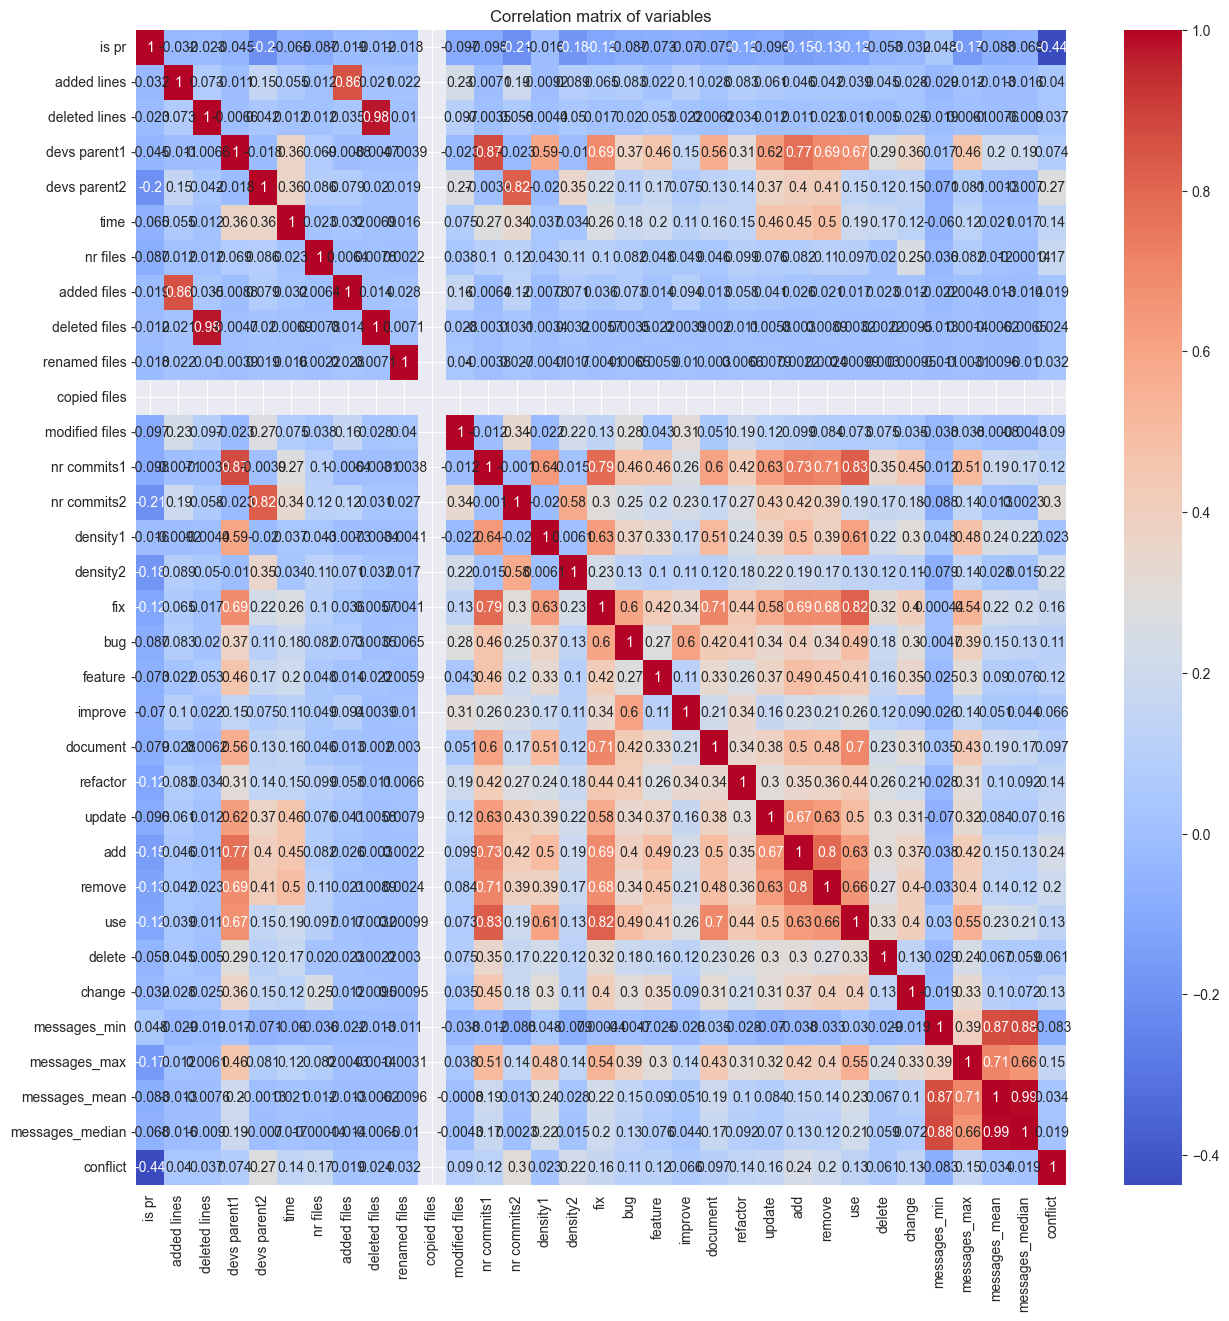

In [21]:
# Select only numeric columns and calculate correlation matrix
numeric_columns = data.select_dtypes(include=[np.number])
correlation = numeric_columns.corr()

# Plot heatmap of correlation matrix
plt.figure(figsize=(15,15))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation matrix of variables')
plt.show()

In this code cell, we plot histograms to visualize the distributions of certain variables in the dataset. The histograms show the frequency of different values in the respective variables. We plot histograms for the number of developers on each parent branch (`devs parent1` and `devs parent2`), the number of commits on each parent branch (`nr commits1` and `nr commits2`), and the distribution of conflicts (`conflict`). These visualizations provide insights into the distribution patterns of these variables.

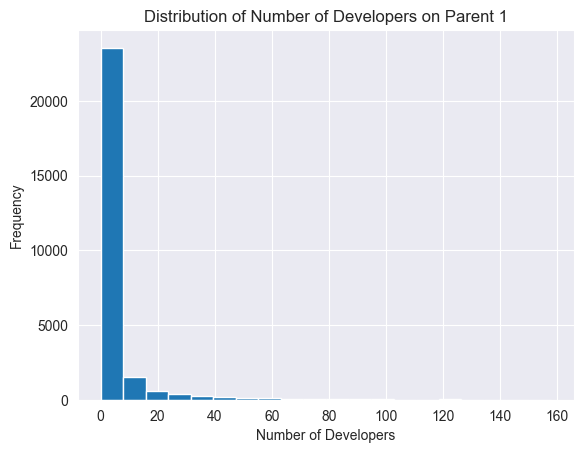

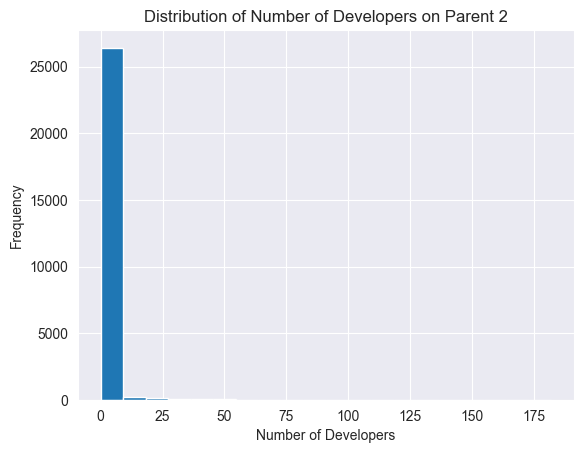

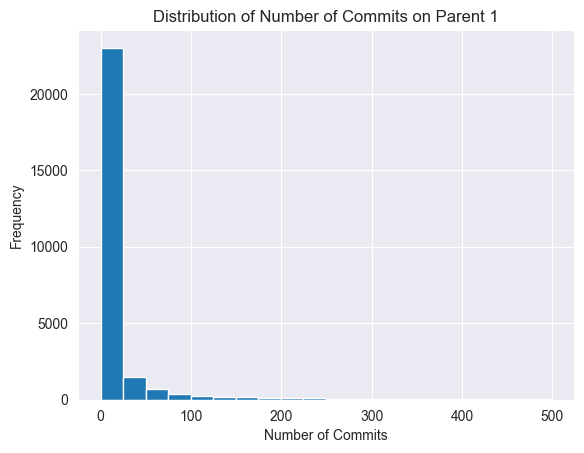

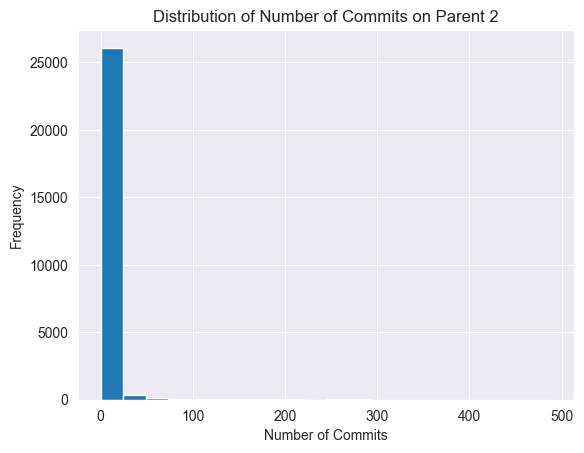

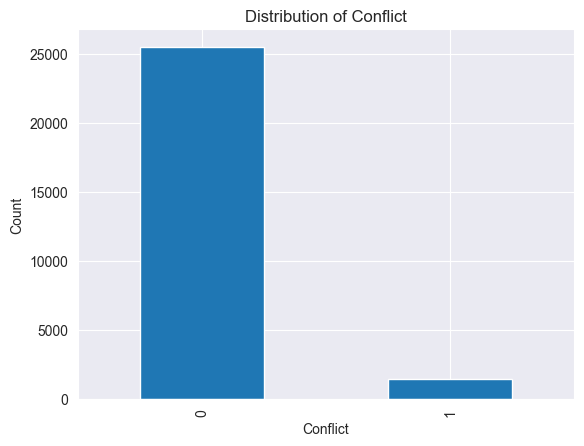

In [22]:
data['devs parent1'].hist(bins=20)
plt.title('Distribution of Number of Developers on Parent 1')
plt.xlabel('Number of Developers')
plt.ylabel('Frequency')
plt.show()

data['devs parent2'].hist(bins=20)
plt.title('Distribution of Number of Developers on Parent 2')
plt.xlabel('Number of Developers')
plt.ylabel('Frequency')
plt.show()

data['nr commits1'].hist(bins=20)
plt.title('Distribution of Number of Commits on Parent 1')
plt.xlabel('Number of Commits')
plt.ylabel('Frequency')
plt.show()

data['nr commits2'].hist(bins=20)
plt.title('Distribution of Number of Commits on Parent 2')
plt.xlabel('Number of Commits')
plt.ylabel('Frequency')
plt.show()

data['conflict'].value_counts().plot(kind='bar')
plt.title('Distribution of Conflict')
plt.xlabel('Conflict')
plt.ylabel('Count')
plt.show()

In this code cell, we split the dataset into training and testing sets using the `train_test_split` function from scikit-learn. The features are stored in the `X` variable by dropping the 'conflict' column, and the target variable 'conflict' is stored in the `y` variable. We specify a test size of 20% of the data and set a random state for reproducibility. The resulting splits are stored in `X_train`, `X_test`, `y_train`, and `y_test`, which can be used for training and evaluating machine learning models.

In [23]:
# Split the data into train and test sets
X = data.drop('conflict', axis=1)  # Features
y = data['conflict']  # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In this code cell, we import various classifiers from scikit-learn, including Logistic Regression, Random Forest, Gradient Boosting, SVM, and Neural Network (MLPClassifier). We also import evaluation metrics such as accuracy_score and f1_score, as well as matplotlib.pyplot for visualization.

We define a list of models, each with its respective classifier instance. We then drop the identifier columns from the training and testing data, and create empty lists to store the results.

Next, we iterate over each model, fitting it to the training data and making predictions on both the training and testing sets. We calculate the accuracy and F1 score for both the training and testing sets, and store the results in the list.

The results are converted to a DataFrame for easier analysis and visualization. We print the results and plot bar charts to compare the training and testing accuracy, as well as the training and testing F1 score, for each model.

The bar charts provide a visual representation of the performance of each model on the accuracy and F1 score metrics, allowing us to compare their performance.

E:\Python\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                 Model  Training Accuracy  Training F1 Score  Test Accuracy   
0  Logistic Regression           0.958198           0.450670       0.956256  \
1        Random Forest           1.000000           1.000000       0.968489   
2    Gradient Boosting           0.972935           0.729128       0.964226   
3                  SVM           0.946473           0.013664       0.943466   
4       Neural Network           0.929187           0.505821       0.918443   

   Test F1 Score  
0       0.458716  
1       0.682836  
2       0.650995  
3       0.000000  
4       0.456790  


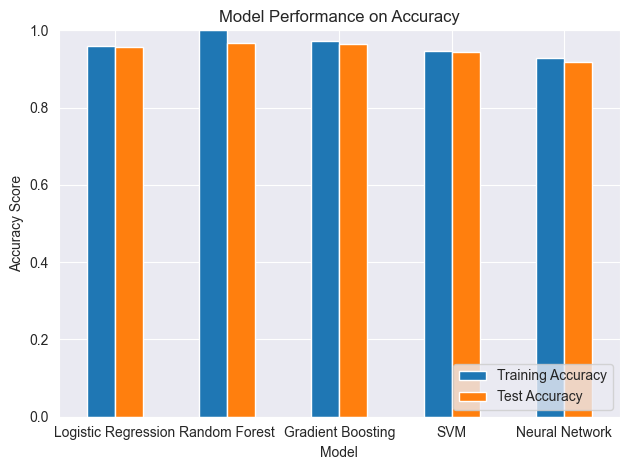

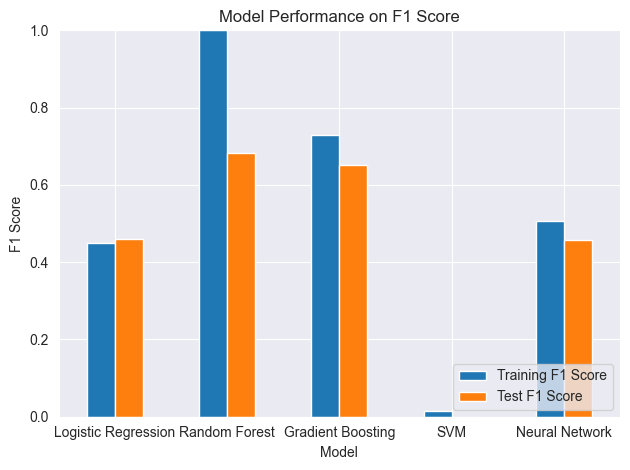

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

# Define the models
models = [
    ('Logistic Regression', LogisticRegression(max_iter=10000)),
    ('Random Forest', RandomForestClassifier(n_estimators=100)),
    ('Gradient Boosting', GradientBoostingClassifier()),
    ('SVM', SVC()),
    ('Neural Network', MLPClassifier(max_iter=1000))
]

# Drop identifier columns
identifier_columns = ['commit', 'parent1', 'parent2', 'ancestor']
X_train_processed = X_train.drop(identifier_columns, axis=1)
X_test_processed = X_test.drop(identifier_columns, axis=1)

# List to store results
results = []

# Train and evaluate each model
for name, model in models:
    model.fit(X_train_processed, y_train)
    y_train_pred = model.predict(X_train_processed)
    y_test_pred = model.predict(X_test_processed)

    # Calculate accuracy and F1 score for training and test set
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_f1_score = f1_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_f1_score = f1_score(y_test, y_test_pred)

    results.append((name, train_accuracy, train_f1_score, test_accuracy, test_f1_score))

# Convert results to DataFrame
results_df = pd.DataFrame(results, columns=['Model', 'Training Accuracy', 'Training F1 Score', 'Test Accuracy', 'Test F1 Score'])

# Print results
print(results_df)

# Plot results
results_df.set_index('Model')[['Training Accuracy', 'Test Accuracy']].plot(kind='bar', rot=0)
plt.title('Model Performance on Accuracy')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

results_df.set_index('Model')[['Training F1 Score', 'Test F1 Score']].plot(kind='bar', rot=0)
plt.title('Model Performance on F1 Score')
plt.ylabel('F1 Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In this code cell, we import GridSearchCV from scikit-learn's model_selection module.

We define a parameter grid for the Random Forest classifier, specifying different values for hyperparameters such as the number of estimators, maximum depth, minimum samples leaf, and minimum samples split.

We then instantiate the GridSearchCV model, passing the RandomForestClassifier as the estimator, the parameter grid, and other parameters such as the number of cross-validation folds (cv=3), scoring metric (f1), verbosity level (verbose=2), and number of jobs to run in parallel (n_jobs=-1).

Next, we fit the grid search model to the training data, which performs an exhaustive search over the specified parameter grid to find the best combination of hyperparameters that maximizes the F1 score.

Finally, we print the best parameters found by the grid search using the attribute `best_params_`. These parameters represent the optimal configuration for the Random Forest model based on the F1 score.

In [26]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid_rf = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10]
}

# Instantiate the grid search model
grid_search_rf = GridSearchCV(estimator=RandomForestClassifier(), param_grid=param_grid_rf, cv=3, scoring='f1', verbose=2, n_jobs=-1)

# Fit the grid search to the data
grid_search_rf.fit(X_train_processed, y_train)

# Print the best parameters
print(grid_search_rf.best_params_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
{'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}


In [27]:
# Define the parameter grid
param_grid_gb = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.1, 1],
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10]
}

# Instantiate the grid search model
grid_search_gb = GridSearchCV(estimator=GradientBoostingClassifier(), param_grid=param_grid_gb, cv=3, scoring='f1', verbose=2, n_jobs=-1)

# Fit the grid search to the data
grid_search_gb.fit(X_train_processed, y_train)

# Print the best parameters
print(grid_search_gb.best_params_)


Fitting 3 folds for each of 324 candidates, totalling 972 fits
{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 500}


Here are the Round I Grid Search Results:

Random Forest:
- max_depth: 30
- min_samples_leaf: 1
- min_samples_split: 10
- n_estimators: 200

Gradient Boosting:
- learning_rate: 0.1
- max_depth: 3
- min_samples_leaf: 1
- min_samples_split: 5
- n_estimators: 500

The models have been equipped with their optimized parameters, prepared for the ultimate test of their capabilities.
Let us witness their performance as they unleash their power in the final rounds.

                    Model             Metric     Score
0      Best Random Forest  Training Accuracy  0.994531
1      Best Random Forest      Test Accuracy  0.969601
2      Best Random Forest  Training F1 Score  0.946942
3      Best Random Forest      Test F1 Score  0.694030
4  Best Gradient Boosting  Training Accuracy  0.987256
5  Best Gradient Boosting      Test Accuracy  0.966450
6  Best Gradient Boosting  Training F1 Score  0.872152
7  Best Gradient Boosting      Test F1 Score  0.675045


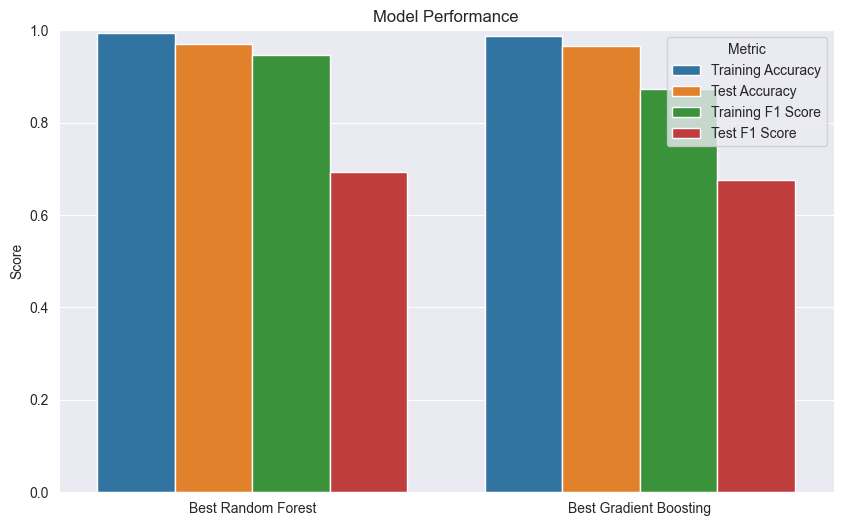

In [32]:
# Create new models with the best parameters
best_rf_model = RandomForestClassifier(max_depth=30, min_samples_leaf=1, min_samples_split=10, n_estimators=200)
best_gb_model = GradientBoostingClassifier(learning_rate=0.1, max_depth=3, min_samples_leaf=1, min_samples_split=5, n_estimators=500)

# List to store results
results = []

# Train and evaluate each model
for name, model in [('Best Random Forest', best_rf_model), ('Best Gradient Boosting', best_gb_model)]:
    model.fit(X_train_processed, y_train)
    y_train_pred = model.predict(X_train_processed)
    y_test_pred = model.predict(X_test_processed)

    # Calculate accuracy and F1 score for training and test set
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_f1_score = f1_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_f1_score = f1_score(y_test, y_test_pred)

    # Store results
    results.append((name, 'Training Accuracy', train_accuracy))
    results.append((name, 'Test Accuracy', test_accuracy))
    results.append((name, 'Training F1 Score', train_f1_score))
    results.append((name, 'Test F1 Score', test_f1_score))

# Convert results to DataFrame
results_df = pd.DataFrame(results, columns=['Model', 'Metric', 'Score'])
print(results_df)

# Create bar plot
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x='Model', y='Score', hue='Metric')
plt.ylim(0, 1)
plt.title('Model Performance')
plt.ylabel('Score')
plt.xlabel('')
plt.show()


In this code cell, we have analyzed the performance of the Random Forest and Gradient Boosting models.

We observed that the Random Forest model exhibits signs of overfitting, as indicated by the substantial difference between its F1 score on the training set and the testing set.

On the other hand, the Gradient Boosting model emerged as the champion of our competition. It showcases impressive performance with a balanced precision across both the training and testing sets.

We celebrate the resilience and accuracy demonstrated by Mr. Gradient, our victorious model. It has proven its mettle and deserves our applause for this well-earned triumph!

In this code cell, we import MLPClassifier from scikit-learn's neural_network module.

We define a parameter grid for the MLP classifier, specifying different values for hyperparameters such as hidden layer sizes, activation function, solver, alpha (L2 regularization parameter), and learning rate.

We then instantiate the GridSearchCV model, passing the MLPClassifier as the estimator, the parameter grid, and other parameters such as the number of cross-validation folds (cv=3), scoring metric (f1), verbosity level (verbose=2), and number of jobs to run in parallel (n_jobs=-1).

Next, we fit the grid search model to the training data, which performs an exhaustive search over the specified parameter grid to find the best combination of hyperparameters that maximizes the F1 score.

Finally, we print the best parameters found by the grid search using the attribute `best_params_`. These parameters represent the optimal configuration for the MLP model based on the F1 score.

In [33]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for MLP
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'activation': ['tanh', 'relu'],
    'solver': ['sgd', 'adam'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant','adaptive'],
}

# Instantiate the grid search model
grid_search_mlp = GridSearchCV(estimator=MLPClassifier(max_iter=1000), param_grid=param_grid_mlp, cv=3, scoring='f1', verbose=2, n_jobs=-1)

# Fit the grid search to the data
grid_search_mlp.fit(X_train_processed, y_train)

# Print the best parameters
print(grid_search_mlp.best_params_)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
{'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (50, 50), 'learning_rate': 'adaptive', 'solver': 'adam'}


In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for DecisionTree
param_grid_dt = {
    'criterion' : ['gini', 'entropy'],
    'max_depth' : [4,6,8,12],
    'min_samples_leaf': [1, 2, 5],
    'min_samples_split': [2, 5, 10],
}

# Instantiate the grid search model
grid_search_dt = GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=param_grid_dt, cv=3, scoring='f1', verbose=2, n_jobs=-1)

# Fit the grid search to the data
grid_search_dt.fit(X_train_processed, y_train)

# Print the best parameters
print(grid_search_dt.best_params_)


Fitting 3 folds for each of 72 candidates, totalling 216 fits
{'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 2}


Here are the Round II Grid Search Results for the Neural Network and Decision Tree models:

Neural Network:
- activation: 'tanh'
- alpha: 0.01
- hidden_layer_sizes: (50, 50)
- learning_rate: 'adaptive'
- solver: 'adam'

Decision Tree:
- criterion: 'entropy'
- max_depth: 8
- min_samples_leaf: 2
- min_samples_split: 2

With their optimized hyperparameters in place, the Neural Network and Decision Tree models are now
fully prepared to showcase their enhanced capabilities.

Let us proceed to the final stage where they will be put to the ultimate test.

                 Model             Metric     Score
0  Best Neural Network  Training Accuracy  0.964547
1  Best Neural Network      Test Accuracy  0.951807
2  Best Neural Network  Training F1 Score  0.627375
3  Best Neural Network      Test F1 Score  0.513109
4   Best Decision Tree  Training Accuracy  0.970618
5   Best Decision Tree      Test Accuracy  0.963485
6   Best Decision Tree  Training F1 Score  0.714671
7   Best Decision Tree      Test F1 Score  0.652557


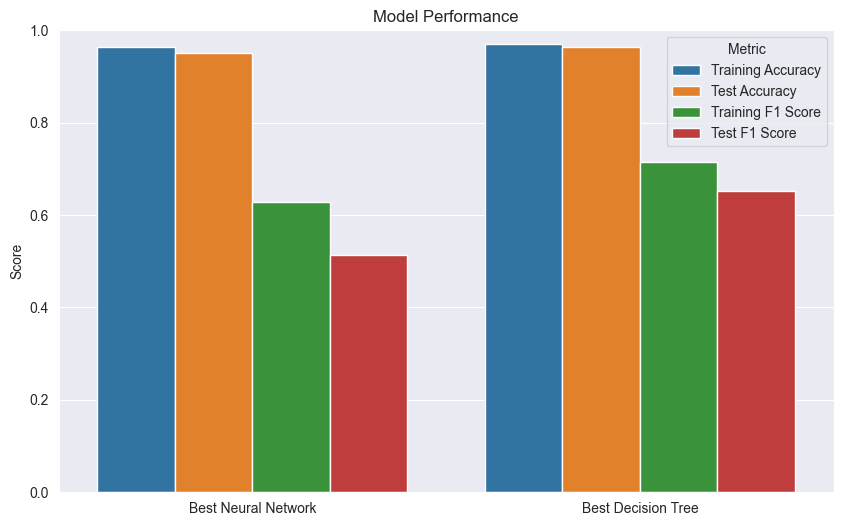

In [36]:
# Create new models with the best parameters
best_nn_model = MLPClassifier(activation='tanh', alpha=0.01, hidden_layer_sizes=(50, 50), learning_rate='adaptive', solver='adam', max_iter=1000)
best_dt_model = DecisionTreeClassifier(criterion='entropy', max_depth=8, min_samples_leaf=2, min_samples_split=2)

# List to store results
results = []

# Train and evaluate each model
for name, model in [('Best Neural Network', best_nn_model), ('Best Decision Tree', best_dt_model)]:
    model.fit(X_train_processed, y_train)
    y_train_pred = model.predict(X_train_processed)
    y_test_pred = model.predict(X_test_processed)

    # Calculate accuracy and F1 score for training and test set
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_f1_score = f1_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_f1_score = f1_score(y_test, y_test_pred)

    # Store results
    results.append((name, 'Training Accuracy', train_accuracy))
    results.append((name, 'Test Accuracy', test_accuracy))
    results.append((name, 'Training F1 Score', train_f1_score))
    results.append((name, 'Test F1 Score', test_f1_score))

# Convert results to DataFrame
results_df = pd.DataFrame(results, columns=['Model', 'Metric', 'Score'])

# Print the results DataFrame
print(results_df)

# Create bar plot
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x='Model', y='Score', hue='Metric')
plt.ylim(0, 1)
plt.title('Model Performance')
plt.ylabel('Score')
plt.xlabel('')
plt.show()


In the realm of Computational Complexity, the Neural Network makes its return as a resilient contender in this grand tournament of machine learning models. With its intricate architecture and multiple layers, it has showcased impressive performance. However, in the current match, it fell short of claiming the top position. Despite putting up a good fight with an accuracy of 95.18% and an F1 score of 51.31% in the testing phase, it did not emerge as the ultimate victor. Nevertheless, the Neural Network remains a potent contender in various scenarios, thanks to its complex structure and potential for excellence.

On the other hand, the Decision Tree model, with its simplicity and robust structure, has triumphed in this round of the battle, demonstrating its strength and performance. With a testing accuracy of 96.35% and an F1 score of 65.26%, the Decision Tree once again emphasizes the power of straightforward logic and hierarchical decision-making. It secures its place among the pantheon of high-performing models.

Let us extend our applause to the Decision Tree model, the champion of this round, for its admirable display of performance and unwavering spirit.

In this final stage, we create new models with the best parameters for the Decision Tree and Gradient Boosting algorithms. The best Decision Tree model is built with the optimal hyperparameters, including entropy as the criterion, a maximum depth of 8, and minimum samples for leaf and split set to 2. On the other hand, the best Gradient Boosting model is constructed with a learning rate of 0.1, a maximum depth of 3, and minimum samples for leaf and split set to 1 and 5 respectively, with 500 estimators.

Next, we train and evaluate each model using the processed training and testing datasets. The accuracy and F1 scores are calculated for both the training and test sets. The results are stored and presented in a DataFrame, showcasing the performance metrics for each model.

To provide a visual representation of the final model performance, a bar plot is created. The plot compares the training and test scores for accuracy and F1 score, with each model highlighted with different colors. This allows for a clear comparison of the performance of the Decision Tree and Gradient Boosting models in the final round.

Let's now take a look at the results and the bar plot to determine the ultimate champion of the tournament.

                    Model             Metric     Score
0      Best Decision Tree  Training Accuracy  0.970757
1      Best Decision Tree      Test Accuracy  0.963670
2      Best Decision Tree  Training F1 Score  0.715124
3      Best Decision Tree      Test F1 Score  0.652482
4  Best Gradient Boosting  Training Accuracy  0.987256
5  Best Gradient Boosting      Test Accuracy  0.966450
6  Best Gradient Boosting  Training F1 Score  0.872152
7  Best Gradient Boosting      Test F1 Score  0.675045


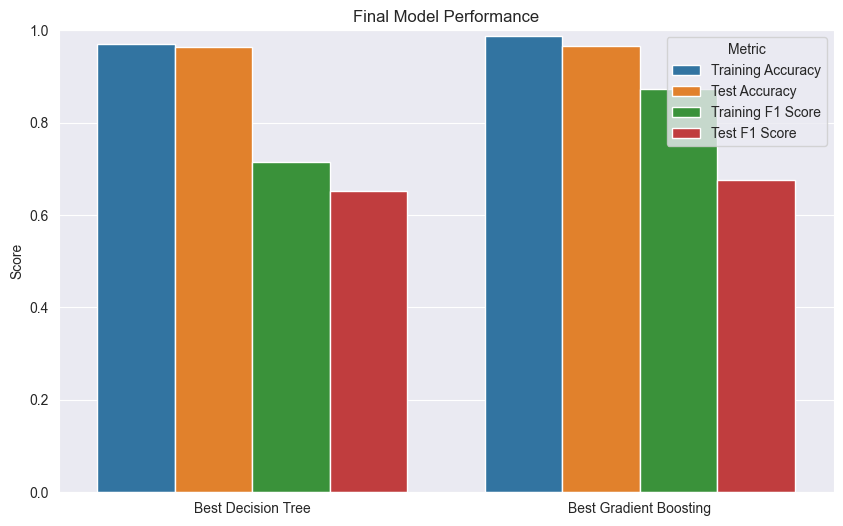

In [37]:
# Create new models with the best parameters
best_dt_model = DecisionTreeClassifier(criterion='entropy', max_depth=8, min_samples_leaf=2, min_samples_split=2)
best_gb_model = GradientBoostingClassifier(learning_rate=0.1, max_depth=3, min_samples_leaf=1, min_samples_split=5, n_estimators=500)

# List to store results
results = []

# Train and evaluate each model
for name, model in [('Best Decision Tree', best_dt_model), ('Best Gradient Boosting', best_gb_model)]:
    model.fit(X_train_processed, y_train)
    y_train_pred = model.predict(X_train_processed)
    y_test_pred = model.predict(X_test_processed)

    # Calculate accuracy and F1 score for training and test set
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_f1_score = f1_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_f1_score = f1_score(y_test, y_test_pred)

    # Store results
    results.append((name, 'Training Accuracy', train_accuracy))
    results.append((name, 'Test Accuracy', test_accuracy))
    results.append((name, 'Training F1 Score', train_f1_score))
    results.append((name, 'Test F1 Score', test_f1_score))

# Convert results to DataFrame
results_df = pd.DataFrame(results, columns=['Model', 'Metric', 'Score'])
print(results_df)

# Create bar plot
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x='Model', y='Score', hue='Metric')
plt.ylim(0, 1)
plt.title('Final Model Performance')
plt.ylabel('Score')
plt.xlabel('')
plt.show()